In [4]:
%load_ext autoreload
%autoreload 2

In [14]:
import numpy as np
import pandas as pd
import time
import scipy.stats as spst
import scipy.special as spsp
from fetch_deribit_data import *
from callibration_32model import *

import sys
sys.path.insert(sys.path.index("")+1, "C:/Users/27261/Desktop/3_Courses in PHBS/3_09_AppliedStochasticProcess/Project_sv32_EMC")
import pyfeng as pf
import pyfeng.ex as pfex
from utils import *

In [113]:
if __name__ == "__main__":
    # 放宽窗口时间，收集充足的散点
    periods = {
        "1_Pre_Shock":  ("2025-10-10 20:50:00", "2025-10-10 21:00:00"),
        "2_Crash":      ("2025-10-10 21:15:00", "2025-10-10 21:20:00"),
        "3_Recovery":   ("2025-10-10 23:50:00", "2025-10-11 00:00:00")
    }
    
    for phase_name, (start_t, end_t) in periods.items():
        print(f"\n====== 正在处理阶段: {phase_name} ({start_t} 到 {end_t}) ======")
        raw_df = fetch_deribit_trades_fast(start_t, end_t)
        if not raw_df.empty:
            # 1. 保存未过滤的原始数据 (Raw Data)
            raw_csv_filename = f"Deribit_RAW_{phase_name}.csv"
            raw_df.to_csv(raw_csv_filename, index=False)
            print(f"[成功] 阶段 {phase_name} 的原始成交记录 ({len(raw_df)} 条) 已保存至 {raw_csv_filename}")
        else:
            print(f"[警告] 阶段 {phase_name} 未拉取到数据！")


====== 正在处理阶段: 1_Pre_Shock (2025-10-10 20:50:00 到 2025-10-10 21:00:00) ======
  [引擎启动] 划分为 2 个并发块，安全全速抓取...
  [并发进度] 已完成 2/2 块 (累计获取 2153 条成交记录)...
  所有任务结束，正在重组与去重...
[成功] 阶段 1_Pre_Shock 的原始成交记录 (1110 条) 已保存至 Deribit_RAW_1_Pre_Shock.csv

====== 正在处理阶段: 2_Crash (2025-10-10 21:15:00 到 2025-10-10 21:20:00) ======
  [引擎启动] 划分为 1 个并发块，安全全速抓取...
  [并发进度] 已完成 1/1 块 (累计获取 947 条成交记录)...
  所有任务结束，正在重组与去重...
[成功] 阶段 2_Crash 的原始成交记录 (774 条) 已保存至 Deribit_RAW_2_Crash.csv

====== 正在处理阶段: 3_Recovery (2025-10-10 23:50:00 到 2025-10-11 00:00:00) ======
  [引擎启动] 划分为 2 个并发块，安全全速抓取...
  [并发进度] 已完成 2/2 块 (累计获取 645 条成交记录)...
  所有任务结束，正在重组与去重...
[成功] 阶段 3_Recovery 的原始成交记录 (559 条) 已保存至 Deribit_RAW_3_Recovery.csv


In [8]:
if __name__ == "__main__":
    # Mapping your generated CSV files
    phases = {
        "1_Pre_Shock": "Deribit_RAW_1_Pre_Shock.csv",
        "2_Crash":     "Deribit_RAW_2_Crash.csv",
        "3_Recovery":  "Deribit_RAW_3_Recovery.csv"
    }
    
    for name, file in phases.items():
        analyze_and_plot_pie_chart(name, file)


>>> Processing Phase: 1_Pre_Shock (Deribit_RAW_1_Pre_Shock.csv)
[Success] Saved chart as Chart_1_Pre_Shock.png

>>> Processing Phase: 2_Crash (Deribit_RAW_2_Crash.csv)
[Success] Saved chart as Chart_2_Crash.png

>>> Processing Phase: 3_Recovery (Deribit_RAW_3_Recovery.csv)
[Success] Saved chart as Chart_3_Recovery.png


In [123]:
# 运行代码
if __name__ == "__main__":
    # 闪崩发生在 2025年10月10日，我们取这之前 180 天的数据
    fetch_dvol_data(end_date_str='2025-10-10', days_lookback=180)
    kappa, theta = estimate_32_parameters()
    print(f"kappa_estimated = {kappa}")
    print(f"theta_estimated = {theta}, (which means iv={np.sqrt(theta)*100:.2f}%)")

正在从 Deribit 抓取 2025-10-10 前 180 天的 BTC DVOL 数据 (UTC)...
✅ 成功获取 181 天的 DVOL 数据并保存。

 基础Stata风格回归表（statsmodels原生）
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.042
Model:                            OLS   Adj. R-squared (uncentered):              0.031
Method:                 Least Squares   F-statistic:                              3.923
Date:                Wed, 25 Mar 2026   Prob (F-statistic):                      0.0215
Time:                        10:36:02   Log-Likelihood:                          91.842
No. Observations:                 180   AIC:                                     -179.7
Df Residuals:                     178   BIC:                                     -173.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
        

In [12]:
if __name__ == "__main__":
    clean_and_split_smart()


📂 正在读取并智能提纯: Deribit_RAW_1_Pre_Shock.csv
  ✅ [20D] 导出至: Deribit_20D_1_Pre_Shock.csv
     -> 锚定交割日: 31OCT25 | 匹配天数: 20.46天 | 有效样本数: 32
  ✅ [6D] 导出至: Deribit_6D_1_Pre_Shock.csv
     -> 锚定交割日: 17OCT25 | 匹配天数: 6.46天 | 有效样本数: 23

📂 正在读取并智能提纯: Deribit_RAW_2_Crash.csv
  ✅ [20D] 导出至: Deribit_20D_2_Crash.csv
     -> 锚定交割日: 31OCT25 | 匹配天数: 20.45天 | 有效样本数: 33
  ✅ [6D] 导出至: Deribit_6D_2_Crash.csv
     -> 锚定交割日: 17OCT25 | 匹配天数: 6.45天 | 有效样本数: 18

📂 正在读取并智能提纯: Deribit_RAW_3_Recovery.csv
  ✅ [20D] 导出至: Deribit_20D_3_Recovery.csv
     -> 锚定交割日: 31OCT25 | 匹配天数: 20.34天 | 有效样本数: 25
  ✅ [6D] 导出至: Deribit_6D_3_Recovery.csv
     -> 锚定交割日: 17OCT25 | 匹配天数: 6.34天 | 有效样本数: 17


正在透视底层数据: Deribit_RAW_1_Pre_Shock.csv

 按有效虚值成交笔数排名:
   -> 距离到期  20.0 天 | 虚值成交量: 244 笔
   -> 距离到期   6.0 天 | 虚值成交量: 128 笔
   -> 距离到期  76.0 天 | 虚值成交量: 103 笔
   -> 距离到期   0.0 天 | 虚值成交量: 100 笔
   -> 距离到期  48.0 天 | 虚值成交量: 87 笔


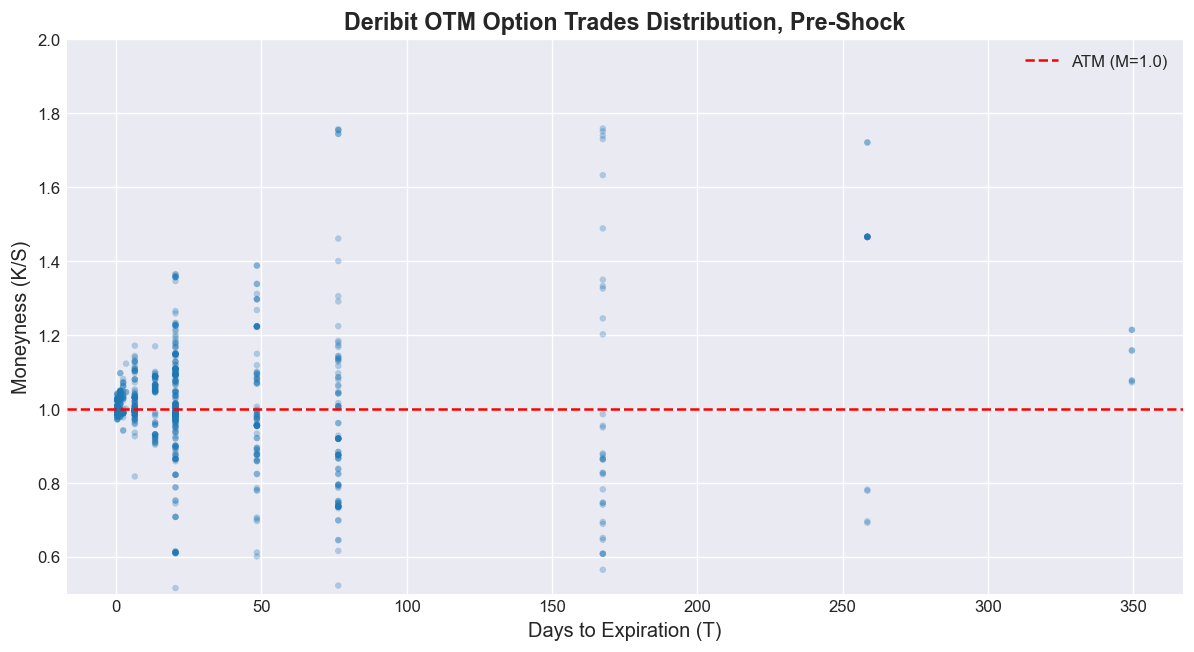

正在透视底层数据: Deribit_RAW_2_Crash.csv

 按有效虚值成交笔数排名:
   -> 距离到期  20.0 天 | 虚值成交量: 238 笔
   -> 距离到期  48.0 天 | 虚值成交量: 103 笔
   -> 距离到期  76.0 天 | 虚值成交量: 93 笔
   -> 距离到期   0.0 天 | 虚值成交量: 52 笔
   -> 距离到期   6.0 天 | 虚值成交量: 43 笔


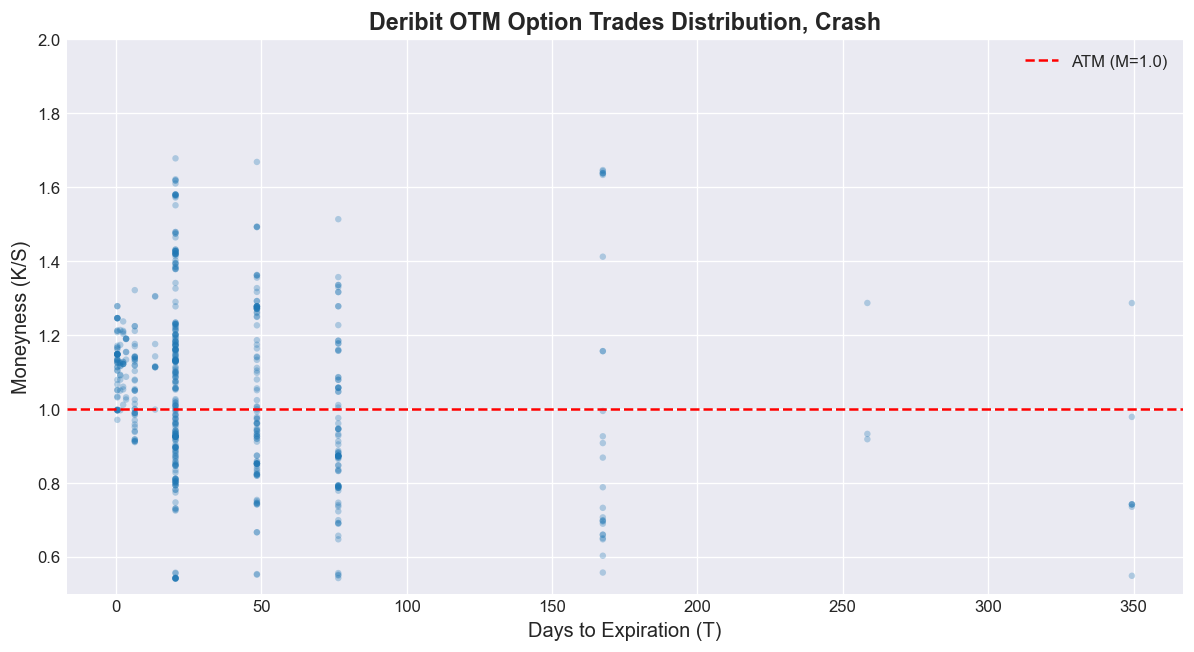

正在透视底层数据: Deribit_RAW_3_Recovery.csv

 按有效虚值成交笔数排名:
   -> 距离到期  20.0 天 | 虚值成交量: 214 笔
   -> 距离到期   6.0 天 | 虚值成交量: 66 笔
   -> 距离到期  48.0 天 | 虚值成交量: 57 笔
   -> 距离到期  76.0 天 | 虚值成交量: 45 笔
   -> 距离到期  13.0 天 | 虚值成交量: 41 笔


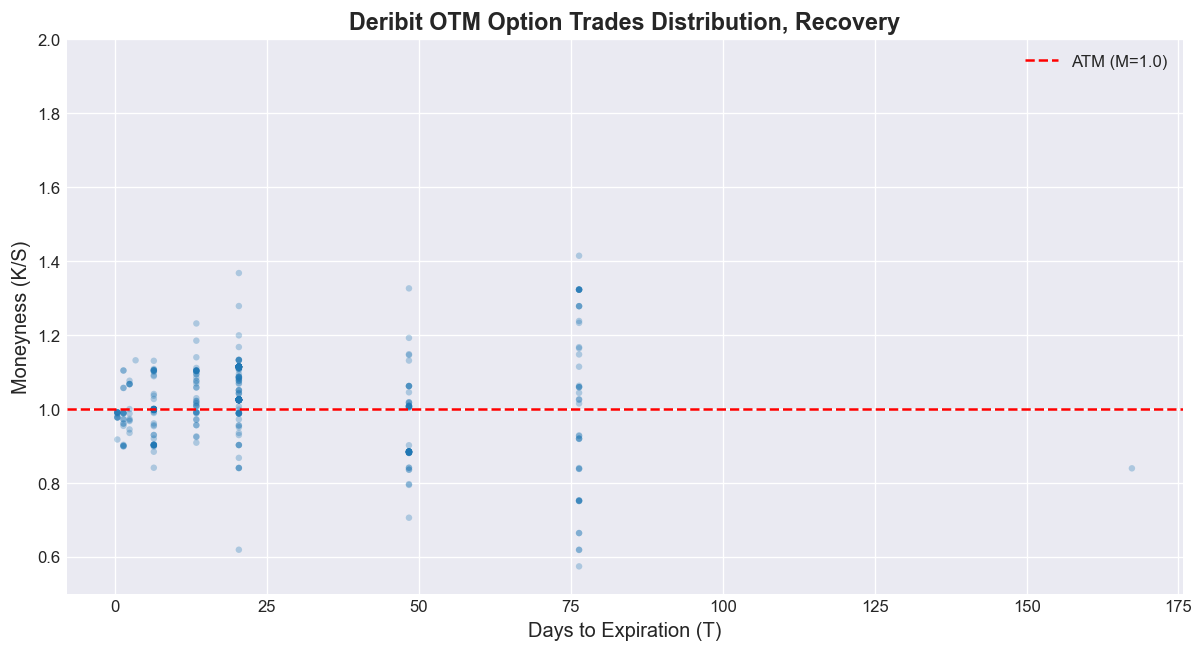

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


if __name__ == "__main__":
    # 替换为你抓到的包含 24 小时的完整 RAW 文件
    liquidity_xray("Deribit_RAW_1_Pre_Shock.csv", "Pre-Shock")
    liquidity_xray("Deribit_RAW_2_Crash.csv", "Crash")
    liquidity_xray("Deribit_RAW_3_Recovery.csv", "Recovery")


正在处理 1. Pre-Shock (纯扩散组)...
  -> ATM IV: 41.9%, VoV: 17.68, Rho: -0.24

正在处理 2. Crash (纯扩散组)...
  -> ATM IV: 55.4%, VoV: 20.00, Rho: -0.11

正在处理 3. Recovery (纯扩散组)...
  -> ATM IV: 47.1%, VoV: 17.81, Rho: -0.22


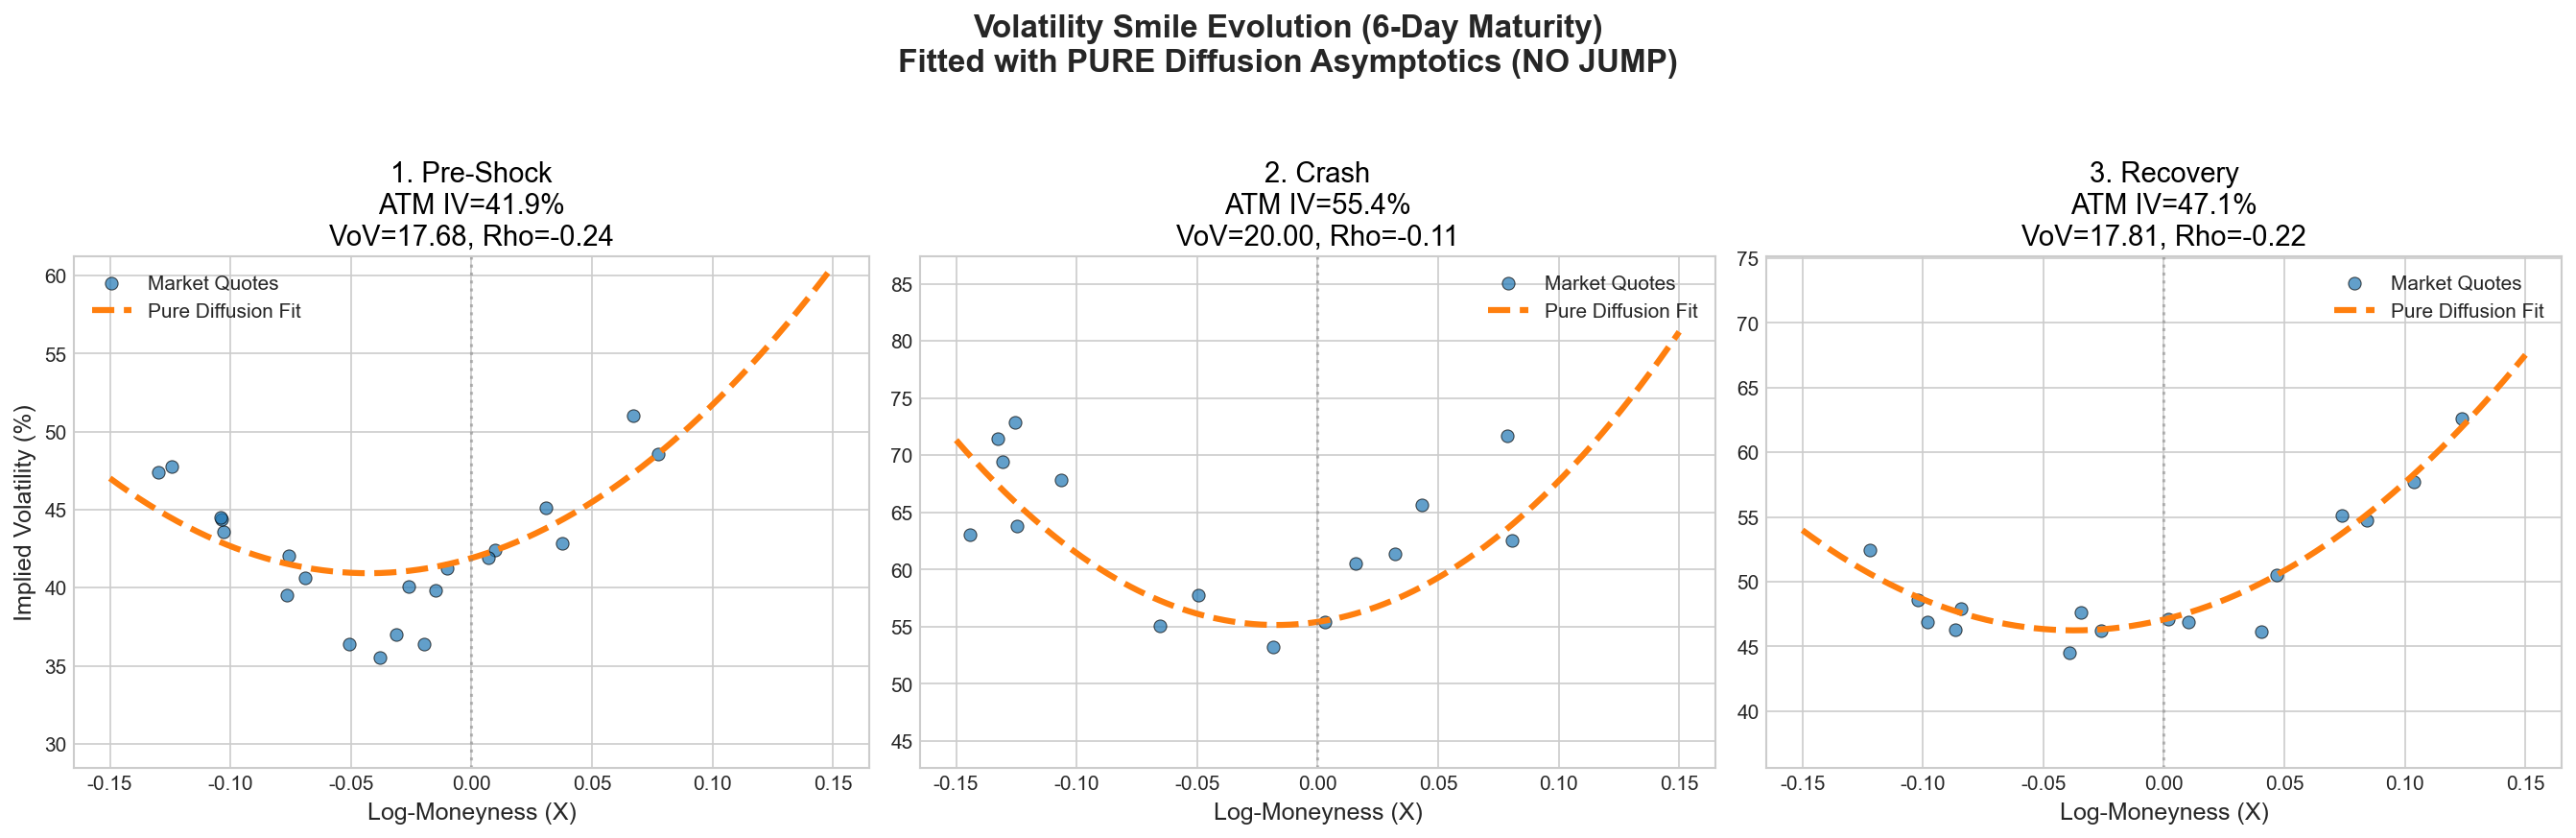


 对照组绘图完成！图片已保存为 Flash_Crash_6D_Evolution_NoJump.png


In [133]:
if __name__ == "__main__":
    run_32_model_no_jump_analysis(days=6)


正在处理 1. Pre-Shock...
  -> ATM IV: 41.9%, VoV: 6.58, Rho: -0.99, Jump Vol: 0.29

正在处理 2. Crash...
  -> ATM IV: 55.4%, VoV: 4.83, Rho: -0.91, Jump Vol: 0.77

正在处理 3. Recovery...
  -> ATM IV: 47.1%, VoV: 3.88, Rho: -0.99, Jump Vol: 0.28


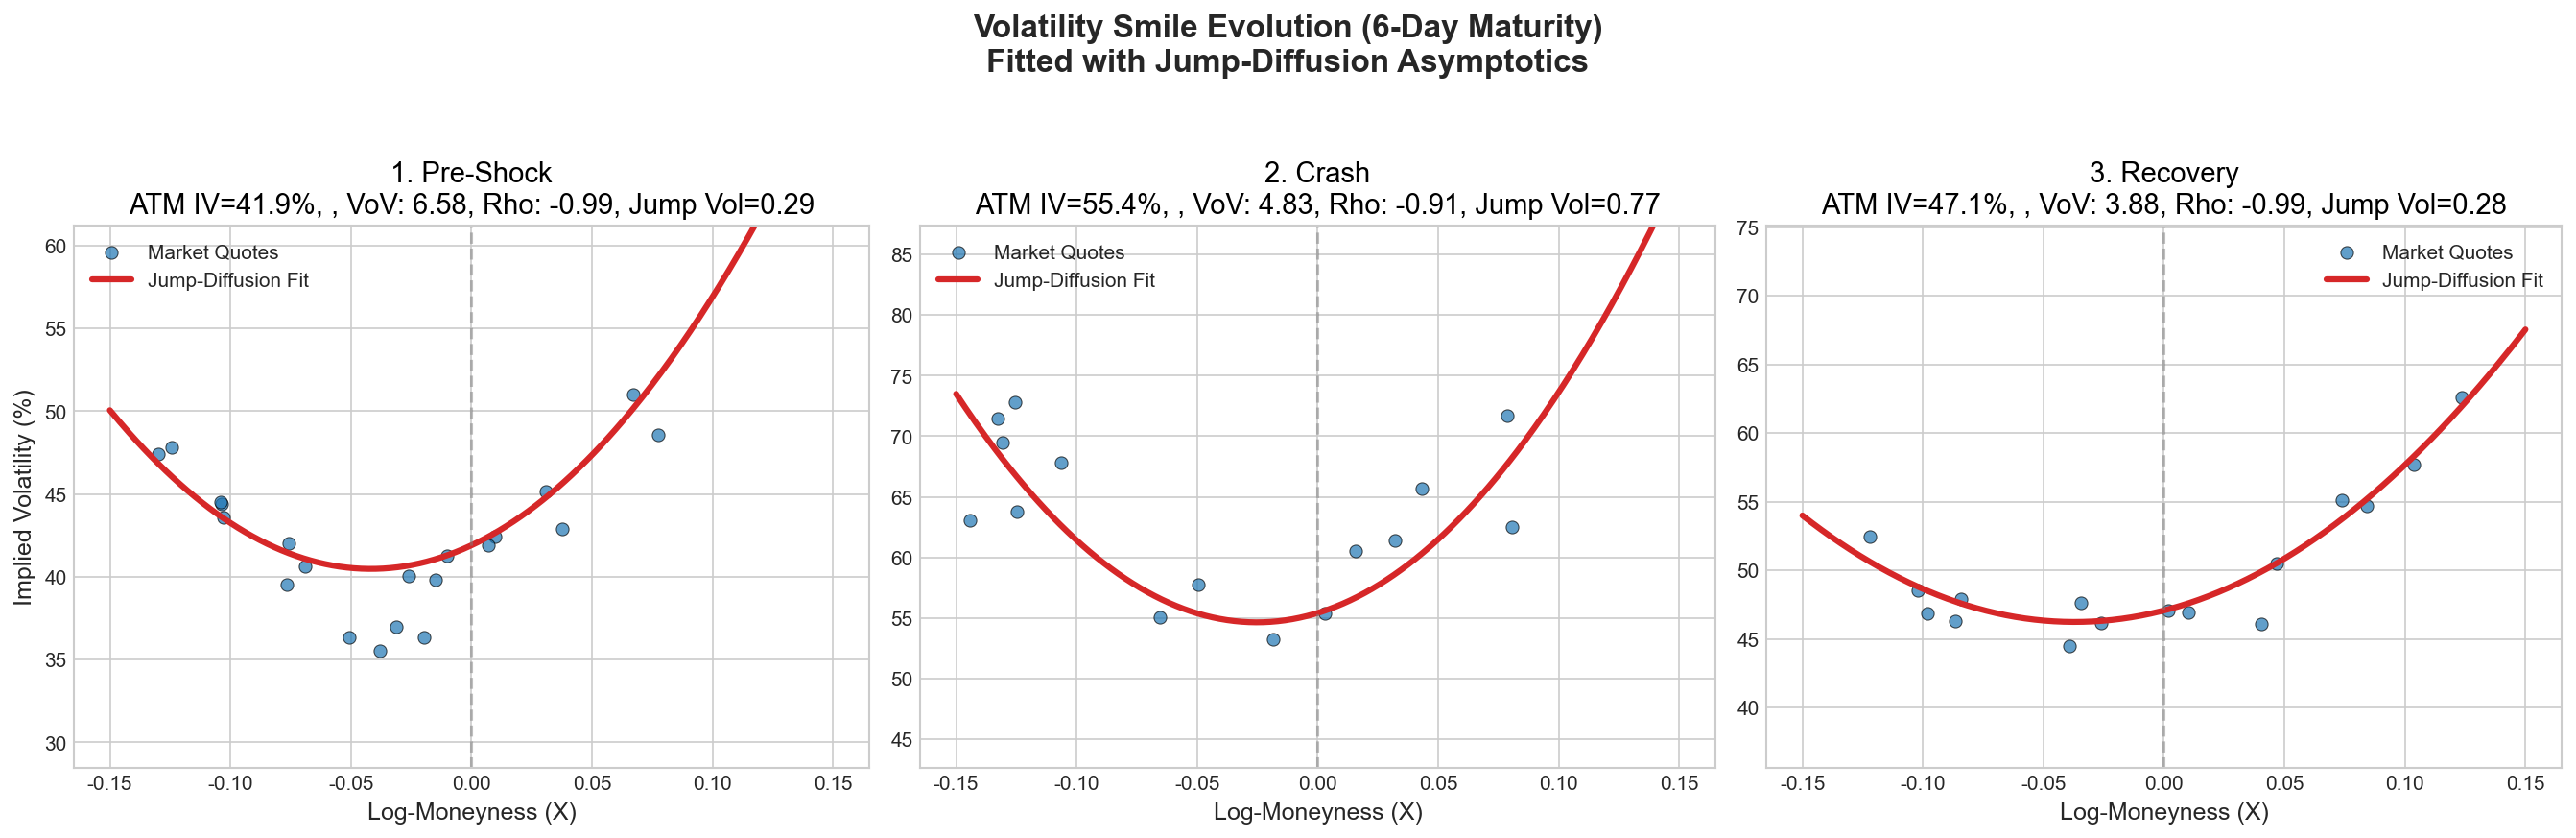


✅ 绘图完成！图片已保存为 Flash_Crash_6D_Evolution.png


In [135]:
if __name__ == "__main__":
    run_32_model_jump_analysis(days=6)